In [30]:
from typing import Annotated, List, TypedDict, Union
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import random
import operator
from tools import web_search
from tools import write_to_vector_db
import sys
sys.path.append("..")

In [2]:
from vectorstore.chrome_store import get_chroma_vectorstore

In [3]:
load_dotenv(override=True)

True

In [4]:
class GraphState(TypedDict):
    #User's original query (e.g., "Why did Spark job X fail?")
    question: str

    #Current generation from the LLM
    generation: str

    #List of retrieved logs, docs or records 
    # Annotated with operator.add so new retrievals append to the list 
    documents: Annotated[List[str], operator.add]   

    #Tracking quality score: 'yes', 'no' or 'maybe'
    is_grounded: str #Hallucination check
    is_relevant: str #Relevance check

    #Counter to prevent infinite loops
    retry_generation_count: int
    kb_retry_count: int
    
    #Log of steps taken (for debugging and transparency)
    #e.g ['retrieved logs', 'failed hallucination check', 'web search spark docs, 'failed relevance check']
    steps: Annotated[List[str], operator.add]

    #Any misc metadata for Jobs (e.g job_id, env, error_code, etc)
    metadata: dict
    #Knowledge Base updates 
    kb_enriched: bool

In [5]:
# --- 2. DATA MODELS FOR STRUCTURED OUTPUT ---
class GradeDocuments(BaseModel):
    binary_score: str = Field(description="Relevant to question, 'yes' or 'no'")

class GradeHallucinations(BaseModel):
    binary_score: str = Field(description="Grounded in facts, 'yes' or 'no'")

In [6]:
### Sanity test for Vector Store setup 
# from langchain_core.documents import Document

# doc = Document(
#     page_content="Spark job job_123 failed due to executor OOM at 2025-09-01T10:22",
#     metadata={"source": "internal_logs"}
# )

# vectorstore.add_documents([doc])

# results = vectorstore.similarity_search("executor OOM job_123", k=1)

# results[0].page_content


In [7]:
# --- 3. NODES ---
llm = ChatOpenAI(model="gpt-4o", temperature=0)
vectorstore = get_chroma_vectorstore()

def retrieve_node(state):
    print("---Retrieving from BFS Vector Store---")
    
    retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={
        "k": 10,
        "score_threshold": 0.60
    }
    )

    #Assuming we have a retriever object
    documents = retriever.invoke(state["question"])

    #Return documents and update the state
    return {"documents": documents, "steps": ["retrieve_documents"]}

In [8]:
HIGH_CONFIDENCE = 0.78   # auto-accept
LOW_CONFIDENCE  = 0.60   # auto-reject

In [9]:
def embedding_relevance_filter(docs, threshold_high=0.78, threshold_low=0.60):
    accepted = []
    borderline = []

    for doc in docs:
        score = doc.metadata.get("similarity", 0)

        if score >= threshold_high:
            accepted.append(doc)
        elif score >= threshold_low:
            borderline.append(doc)
        # else: reject silently

    return accepted, borderline


In [10]:
relevance_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a document relevance grader for Banking & Financial Services
Apache Spark incident analysis.

STRICTNESS RUBRIC:
- Mark YES if the document contains:
  • logs, configs, job IDs, API names, or error codes mentioned in the question
  • partial evidence related to the failure, even if no solution is present
- Mark NO only if the document is clearly about a different job, system,
  technology, or an unrelated error.

IMPORTANT:
- Be liberal: prefer YES if unsure
- Be firm: reject clearly unrelated documents
Return ONLY 'yes' or 'no'."""),
    ("human",
     "Question:\n{question}\n\nDocument:\n{context}")
])


In [11]:
structured_llm_relevance = llm.with_structured_output(GradeDocuments)

In [12]:
def relevance_grader_node(state):
    print("--- HYBRID RELEVANCE CHECK ---")

    question = state["question"]
    docs = state["documents"]

    accepted, borderline = embedding_relevance_filter(docs)

    # LLM fallback only for borderline docs
    for doc in borderline:
        result = structured_llm_relevance.invoke(
            relevance_prompt.format_messages(
                question=question,
                context=doc.page_content
            )
        )

        if result.binary_score.lower() == "yes":
            accepted.append(doc)

    return {
        "documents": accepted,
        "is_relevant": "yes" if accepted else "no",
        "steps": [
            f"embedding_accept:{len(accepted)}",
            f"llm_reviewed:{len(borderline)}"
        ]
    }


In [13]:
##SYSTEM PROMPT FOR GENERATOR NODE 
SYSTEM_PROMPT = """
You are a Senior Data Engineer specializing in BFS (Banking & Financial Services) 
data pipelines and Apache Spark performance tuning. 

Your task is to provide technical solutions based ONLY on the provided Context 
(logs, documentation, and metadata).

### RULES FOR ACCURACY:
1. GROUNDING: Only use information explicitly stated in the context. 
2. BFS CONTEXT: If the question involves job syncs, OOM errors, or data extraction, 
   be specific about error codes and timestamps found in the logs.
3. INSUFFICIENT DATA: If the provided context does not contain enough information 
   to answer the question definitively, you MUST respond exactly with:
   "I don't know - The current knowledge base is insufficient to answer this."

### FORMATTING:
- Use bullet points for technical steps.
- If referencing a specific log entry, quote the relevant line.
- Do not make up configurations or BFS policies.

If you fulfill these conditions and have enough data, provide a detailed 
troubleshooting guide or root cause analysis.
"""

In [14]:
def generate_node(state):
    print("--- GENERATING GROUNDED ANSWER ---")

    question = state["question"]
    documents = state["documents"]

    # If nothing survived relevance grading
    if not documents:
        return {
            "generation": "I don't know - The current knowledge base is insufficient to answer this.",
            "steps": ["generation_skipped_no_context"]
        }

    context = "\n\n".join(
        f"[DOC {i}]\n{doc.page_content}"
        for i, doc in enumerate(documents)
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human",
         "Context:\n{context}\n\n"
         "Question:\n{question}\n\n"
         "Answer strictly using the context above.")
    ])

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({
        "context": context,
        "question": question
    })

    return {
        "generation": response,
        "steps": ["generated_grounded_answer"]
    }


In [15]:
hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system",
     """You are a hallucination detector for a Banking & Financial Services
Apache Spark incident analysis assistant.

RULES:
- Mark NO if the answer includes ANY claim not directly supported
  by the provided documents.
- Mark NO if the answer infers causes, configurations, or fixes
  not explicitly stated in the logs or docs.
- Mark YES only if EVERY statement can be traced to the documents.

IMPORTANT:
- Summarization is allowed
- Rephrasing is allowed
- Logical deduction WITHOUT evidence is NOT allowed

Return ONLY 'yes' or 'no'."""),
    ("human",
     "Documents:\n{documents}\n\nAnswer:\n{generation}")
])

In [16]:
structured_llm_hallucination = llm.with_structured_output(GradeHallucinations)

def hallucination_grader_node(state):
    print("--- CHECKING FOR HALLUCINATIONS ---")

    documents = "\n\n".join(
        f"[DOC {i}]\n{doc.page_content}"
        for i, doc in enumerate(state["documents"])
    )

    result = structured_llm_hallucination.invoke(
        hallucination_prompt.format_messages(
            documents=documents,
            generation=state["generation"]
        )
    )

    return {
        "is_grounded": result.binary_score.lower(),
        "steps": ["hallucination_check"]
    }



### There is a need to check hallucinations at the sentence level also finally my generations must not only be restricted to Spark Assesments but all misc errors

In [17]:
RETRY_SYSTEM_PROMPT = """
You are re-generating an answer after a hallucination was detected.

STRICT RULES:
1. Remove ANY claim not explicitly supported by the provided context.
2. Do NOT infer causes, fixes, or configurations.
3. If evidence is incomplete, respond exactly with:
   "I don't know - The current knowledge base is insufficient to answer this."
4. Prefer quoting logs over explanation.
5. Do NOT repeat the previous answer if unsure.
"""


In [18]:
def retry_generate_node(state):
    print("--- RETRYING GENERATION (STRICT MODE) ---")

    question = state["question"]
    documents = state["documents"]

    context = "\n\n".join(
        f"[DOC {i}]\n{doc.page_content}"
        for i, doc in enumerate(documents)
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", RETRY_SYSTEM_PROMPT),
        ("human",
         "Context:\n{context}\n\n"
         "Question:\n{question}")
    ])

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({
        "context": context,
        "question": question
    })

    return {
        "generation": response,
        "retry_generation_count": state.get("retry_generation_count", 0) + 1,
        "steps": ["retry_generation_strict"]
    }


#### Explore
>Add retry counters per failure type

>Show self-healing prompt diffs

>Add feedback explanations from the hallucination grader

In [19]:
# 1. Define the Rewriter Chain
re_write_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a technical query optimizer for Spark and BFS data pipelines. "
               "Your goal is to take a failing user query and rewrite it into a specific, "
               "technical search term optimized for logs and documentation."),
    ("human", "Original Query: {question}\n"
              "The current results were insufficient. Formulate an improved, "
              "highly specific technical search query.")
])

# Initialize your LLM (e.g., GPT-4o-mini is great for this)
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [ ]:
def improve_kb(state):
    print("--- IMPROVING KNOWLEDGE BASE ---")

    question = state["question"]
    kb_retry_count = state.get("kb_retry_count", 0)

    # 1. Rewrite query for better recall
    improved_query = question_rewriter.invoke({
        "question": question
    })

    print(f"--- REWRITTEN QUERY ---\n{improved_query}")

    # 2. External search (logs, docs, APIs, etc.)
    try:
        new_docs = web_search.invoke({
            "query": improved_query
        })
    except Exception as e:
        print(f"--- WEB SEARCH FAILED: {e} ---")
        new_docs = []

    if not new_docs:
        return {
            "kb_retry_count": kb_retry_count + 1,
            "kb_enriched": False,
            "steps": [
                f"improve_kb_attempt_{kb_retry_count + 1}",
                "web_search_no_results"
            ],
        }
    # 3. Write ONLY valid, new content to vector DB
    stored_chunks = write_to_vector_db(
        docs=new_docs,
        vectorstore=
        
        
    )

    # 4. Did we actually enrich the KB?
    kb_enriched = stored_chunks > 0

    return {
        # IMPORTANT: return only newly fetched docs
        # LangGraph will append via operator.add
        "documents": new_docs,
        "kb_retry_count": kb_retry_count + 1,
        "kb_enriched": kb_enriched,
        "steps": [
            f"improve_kb_attempt_{kb_retry_count + 1}",
            f"stored_chunks:{stored_chunks}"
        ]
    }


In [21]:
def decide_after_relevance(state):
    if state["is_relevant"] == "no":
        return "improve_kb"
    return "generate"

In [22]:
def decide_final_step(state):
     # 1. Hallucination detected → retry generation (once)
    if state["is_grounded"] == "no":
        if state["retry_generation_count"] < 1:
            return "retry_generate"
        else:
            # Reasoning failed even after retry → try more data
            return "improve_kb"
    # 2. Safe but insufficient answer → improve KB (bounded)
    if "I don't know" in state["generation"]:
        if state["kb_retry_count"] < 3 and state.get("kb_enriched", True):
            return "improve_kb"
        else:
            # No more useful knowledge to add
            return "finalize"
    # 3. Grounded and useful answer
    return "finalize"

In [23]:
def decide_after_relevance(state):
    """
    If no relevant documents survived filtering,
    we must try to improve the knowledge base.
    """
    if state["is_relevant"] == "no":
        return "improve_kb"

    return "generate"


In [24]:
workflow = StateGraph(GraphState)

# ------------------
# Add nodes
# ------------------
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("relevance_grader", relevance_grader_node)
workflow.add_node("generate", generate_node)
workflow.add_node("hallucination_grader", hallucination_grader_node)
workflow.add_node("retry_generate", retry_generate_node)
workflow.add_node("improve_kb", improve_kb)

# ------------------
# Entry
# ------------------
workflow.add_edge(START, "retrieve")

# ------------------
# Retrieval → relevance
# ------------------
workflow.add_edge("retrieve", "relevance_grader")

workflow.add_conditional_edges(
    "relevance_grader",
    decide_after_relevance,
    {
        "generate": "generate",
        "improve_kb": "improve_kb",
    },
)

# ------------------
# Improve KB → retrieve again
# ------------------
workflow.add_edge("improve_kb", "retrieve")

# ------------------
# Generate → hallucination check
# ------------------
workflow.add_edge("generate", "hallucination_grader")
workflow.add_edge("retry_generate", "hallucination_grader")

# ------------------
# Final decision router
# ------------------
workflow.add_conditional_edges(
    "hallucination_grader",
    decide_final_step,
    {
        "retry_generate": "retry_generate",
        "improve_kb": "improve_kb",
        "finalize": END,
    },
)

# ------------------
# Compile graph
# ------------------
app = workflow.compile()


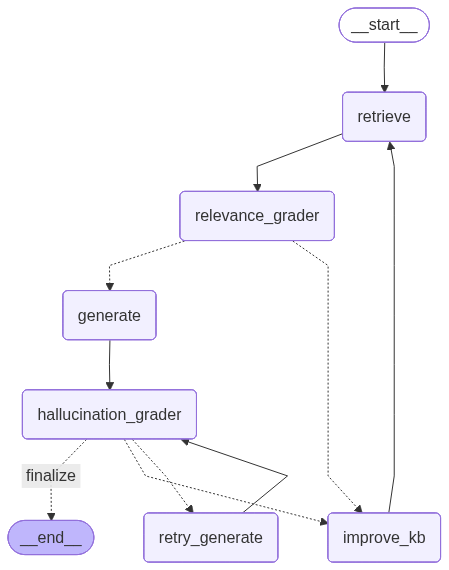

In [25]:
display(Image(app.get_graph().draw_mermaid_png()))

### Unit Tests

In [26]:
from copy import deepcopy
from langchain_core.documents import Document


In [27]:
def run_node(node_fn, state):
    """
    Runs a node with a copy of state and returns output.
    Prevents accidental mutation.
    """
    return node_fn(deepcopy(state))


In [28]:
BASE_STATE = {
    "question": "Why did Spark job job_123 fail?",
    "documents": [],
    "generation": "",
    "is_relevant": "",
    "is_grounded": "",
    "retry_generation_count": 0,
    "kb_retry_count": 0,
    "kb_enriched": True,
    "steps": [],
}


In [29]:
print("vectorstore id:", id(vectorstore))


vectorstore id: 1523042506112


In [30]:
original_as_retriever = vectorstore.as_retriever

class FakeRetriever:
    def invoke(self, query):
        print("FAKE RETRIEVER CALLED")
        return [
            Document(
                page_content="Spark job job_123 failed due to executor OOM",
                metadata={"source": "internal_logs"},
            )
        ]

vectorstore.as_retriever = lambda **kwargs: FakeRetriever()


In [31]:
state = deepcopy(BASE_STATE)
out = retrieve_node(state)

print(out)


---Retrieving from BFS Vector Store---
FAKE RETRIEVER CALLED
{'documents': [Document(metadata={'source': 'internal_logs'}, page_content='Spark job job_123 failed due to executor OOM')], 'steps': ['retrieve_documents']}


In [32]:
print(id(vectorstore))


1523042506112


In [34]:
assert len(out["documents"]) == 1
assert out["steps"] == ["retrieve_documents"]


In [36]:
vectorstore.as_retriever = original_as_retriever


In [53]:
class FakeGrade:
    binary_score = "yes"

class FakeStructuredLLM:
    def invoke(self, *args, **kwargs):
        return FakeGrade()

# Patch
original = structured_llm_relevance
structured_llm_relevance = FakeStructuredLLM()

state = deepcopy(BASE_STATE)
state["documents"] = [
    Document(
        page_content="executor OOM in job_123",
        metadata={"similarity": 0.70}
    )
]

out = relevance_grader_node(state)

assert out["is_relevant"] == "yes"
assert len(out["documents"]) == 1

# Restore
structured_llm_relevance = original


--- HYBRID RELEVANCE CHECK ---


In [41]:
FakeGrade.binary_score = "no"

out = run_node(relevance_grader_node, state)

assert out["is_relevant"] == "no"
assert out["documents"] == []


--- HYBRID RELEVANCE CHECK ---


6️⃣ Unit Test: generate_node

Case 1: No documents → forced refusal

In [42]:
state = deepcopy(BASE_STATE)

out = run_node(generate_node, state)

assert "I don't know" in out["generation"]


--- GENERATING GROUNDED ANSWER ---


In [43]:
print(out)

{'generation': "I don't know - The current knowledge base is insufficient to answer this.", 'steps': ['generation_skipped_no_context']}


Case 2: Documents exist → generation runs

Mock the LLM:

In [46]:
from langchain_core.runnables import RunnableLambda

original_llm = llm

llm = RunnableLambda(lambda _: "Mock answer")

state = deepcopy(BASE_STATE)
state["documents"] = [Document(page_content="log", metadata={})]

out = generate_node(state)

assert out["generation"] == "Mock answer"

llm = original_llm


--- GENERATING GROUNDED ANSWER ---


In [48]:
original_llm = llm

llm = RunnableLambda(lambda _: "Mock answer")
state = deepcopy(BASE_STATE)
state["documents"] = [
    Document(page_content="executor OOM", metadata={})
]

out = run_node(generate_node, state)

assert out["generation"]

llm = original_llm

--- GENERATING GROUNDED ANSWER ---


7️⃣ Unit Test: hallucination_grader_node


Mock hallucination grader

In [ ]:
class FakeGrade:
    binary_score = "yes"

class FakeStructuredLLM:
    def invoke(self, *args, **kwargs):
        return FakeGrade()

# Patch
original = structured_llm_relevance
structured_llm_relevance = FakeStructuredLLM()

state = deepcopy(BASE_STATE)
state["documents"] = [
    Document(
        page_content="executor OOM in job_123",
        metadata={"similarity": 0.70}
    )
]

out = relevance_grader_node(state)

assert out["is_relevant"] == "yes"
assert len(out["documents"]) == 1

# Restore
structured_llm_relevance = original


In [55]:
class FakeHallucination:
    binary_score = "no"

class FakeStructuredLLM:
    def invoke(self, *args, **kwargs):
        return FakeHallucination()

original = structured_llm_hallucination
structured_llm_hallucination = FakeStructuredLLM()
state = deepcopy(BASE_STATE)
state["documents"] = [Document(page_content="log", metadata={})]
state["generation"] = "made up config"

out = hallucination_grader_node(state)

assert out["is_grounded"] == "no"
structured_llm_hallucination = original

--- CHECKING FOR HALLUCINATIONS ---


8️⃣ Unit Test: retry_generate_node

In [60]:
from langchain_core.runnables import RunnableLambda

original_llm = llm
llm = RunnableLambda(lambda _: "Mock answer")

state = deepcopy(BASE_STATE)
state["documents"] = [Document(page_content="log", metadata={})]
out = run_node(retry_generate_node, state)
print(out)

--- RETRYING GENERATION (STRICT MODE) ---
{'generation': 'Mock answer', 'retry_generation_count': 1, 'steps': ['retry_generation_strict']}


In [64]:
assert out["retry_generation_count"] == 1
assert "retry_generation_strict" in out["steps"]
assert out["generation"] == "Mock answer"
llm = original_llm



### Sanity Check after Tavily Implementation

In [26]:
from tools.web_search import web_search_tool

docs = web_search_tool(
    "Spark executor OOM error site:apache.org",
    max_results=3
)

len(docs), docs[0].metadata


(3,
 {'source': 'web_search',
  'tool': 'tavily',
  'url': 'https://spark.apache.org/docs/latest/tuning.html',
  'title': 'Tuning - Spark 4.1.0 Documentation',
  'score': 0.70799106})

9️⃣ Unit Test: improve_kb (CRITICAL)
Mock search + vector write

In [65]:
web_search_tool.invoke = lambda *_: [
    Document(page_content="new log", metadata={"source": "internal_logs"})
]

write_to_vector_db = lambda docs, vectorstore: 3


NameError: name 'web_search_tool' is not defined

In [ ]:
state = deepcopy(BASE_STATE)

out = run_node(improve_kb, state)

assert out["kb_enriched"] is True
assert out["kb_retry_count"] == 1


Negative test (no enrichment)

In [ ]:
write_to_vector_db = lambda *_: 0

out = run_node(improve_kb, state)

assert out["kb_enriched"] is False


🔟 Unit Test: Routers (MOST IMPORTANT)
decide_after_relevance

In [ ]:
state = deepcopy(BASE_STATE)
state["is_relevant"] = "no"

assert decide_after_relevance(state) == "improve_kb"


decide_final_step

Hallucination → retry

In [ ]:
state = deepcopy(BASE_STATE)
state["is_grounded"] = "no"

assert decide_final_step(state) == "retry_generate"


Retry exhausted → improve KB

In [ ]:
state["retry_generation_count"] = 1

assert decide_final_step(state) == "improve_kb"


KB exhausted → finalize

In [ ]:
state = deepcopy(BASE_STATE)
state["generation"] = "I don't know"
state["kb_retry_count"] = 3
state["kb_enriched"] = False

assert decide_final_step(state) == "finalize"
